# Partie A — Prendre en main les données

In [16]:
from pathlib import Path
import numpy as np
from PIL import Image

In [17]:
"""
raw = "../data/raw/"
processed = "../data/processed/"
interim = "../data/interim/"

lots = {
    "lot1" : "../data/raw/HAM10000_images_part_1/"
    "lot2" : "../data/raw/HAM10000_images_part_2/"
}

isic18 = "../data/raw/ISIC_2018_Task3_Training_Input/"
"""

raw = Path("../data/raw/")
processed = Path("../data/processed/")
interim = Path("../data/interim/")
isic18 = raw / "ISIC_2018_Task3_Training_Input/"

lots = {
    "lot1" : raw / "HAM10000_images_part_1/",
    "lot2" : raw / "HAM10000_images_part_2/"
}

In [18]:
import pandas as pd

metadata = pd.read_csv(raw / "HAM10000_metadata.csv")
print("="*50)
print("HAM10000 Metadata")
print(metadata.head())
print("="*50)
print("HAM10000 Metadata Info")
print(metadata.info())
print("="*50)
print("HAM10000 Metadata Description")
print(metadata.describe())
print("="*50)
print("HAM10000 Metadata Class Distribution")
print(metadata["dx"].value_counts())
print("="*50)
print("HAM10000 Metadata Class Distribution (Normalized)")
print(metadata["dx"].value_counts(normalize=True))
print("="*50)



HAM10000 Metadata
     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

        dataset  
0  vidir_modern  
1  vidir_modern  
2  vidir_modern  
3  vidir_modern  
4  vidir_modern  
HAM10000 Metadata Info
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-nul

In [19]:
print("lots items:", lots.items())

lots items: dict_items([('lot1', PosixPath('../data/raw/HAM10000_images_part_1')), ('lot2', PosixPath('../data/raw/HAM10000_images_part_2'))])


In [20]:
# exploration des images 

for nom_lot, dossier in lots.items():
    # Récupérer la première image .jpg du dossier
    fichier_image = next(dossier.glob("*.jpg"))

    # 1. Ouvrir l'image
    img = Image.open(fichier_image)

    # 2. Convertir en tableau numérique
    tableau = np.array(img)


    
    print(f"--- {nom_lot} ({fichier_image.name}) ---")
    print(f"Dimensions (PIL - Largeur × Hauteur) : {img.size}")
    print(f"Mode de couleur                     : {img.mode}")
    print(f"Forme du tableau (NumPy)            : {tableau.shape}")
    print(f"Type de données                     : {tableau.dtype}")
    print(f"Extrait du tableau (coin 2x2, R,V,B):\n{tableau[:2, :2, :]}\n")
    

--- lot1 (ISIC_0026486.jpg) ---
Dimensions (PIL - Largeur × Hauteur) : (600, 450)
Mode de couleur                     : RGB
Forme du tableau (NumPy)            : (450, 600, 3)
Type de données                     : uint8
Extrait du tableau (coin 2x2, R,V,B):
[[[217 130 136]
  [219 134 137]]

 [[220 134 135]
  [220 136 134]]]

--- lot2 (ISIC_0032548.jpg) ---
Dimensions (PIL - Largeur × Hauteur) : (600, 450)
Mode de couleur                     : RGB
Forme du tableau (NumPy)            : (450, 600, 3)
Type de données                     : uint8
Extrait du tableau (coin 2x2, R,V,B):
[[[0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]]]



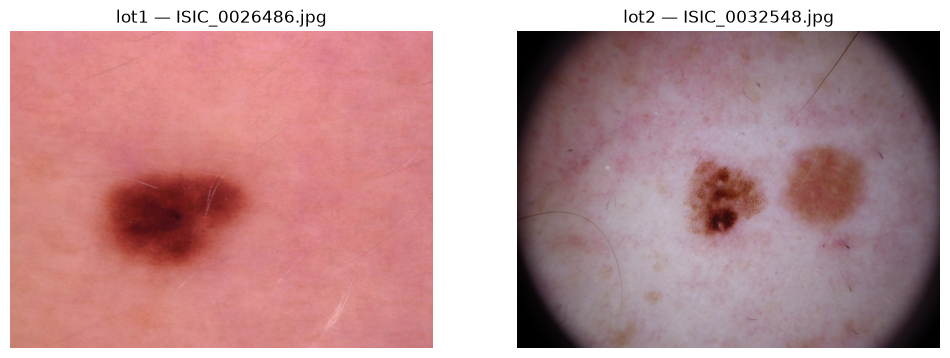

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, len(lots), figsize=(6 * len(lots), 5))

for axe, (nom_lot, dossier) in zip(axes, lots.items()):
    fichier_image = next(dossier.glob("*.jpg"))
    with Image.open(fichier_image) as img:
        axe.imshow(img)
    axe.set_title(f"{nom_lot} — {fichier_image.name}")
    axe.axis("off")

plt.show()

In [22]:
for nom_lot, dossier in lots.items():
    nombre = len(list(dossier.glob("*.jpg")))
    print(f"{nom_lot} : {nombre} images")

lot1 : 5000 images
lot2 : 5015 images


In [23]:
ids_fichiers = {
    fichier.stem
    for dossier in lots.values()
    for fichier in dossier.glob("*.jpg")
}
ids_tableau = set(metadata["image_id"])

print("Images sans ligne dans le CSV :", len(ids_fichiers - ids_tableau))
print("Lignes sans fichier image :", len(ids_tableau - ids_fichiers))
print("Identifiants répétés dans le CSV :", metadata["image_id"].duplicated().sum())

Images sans ligne dans le CSV : 0
Lignes sans fichier image : 0
Identifiants répétés dans le CSV : 0


In [24]:
images_par_lesion = metadata.groupby("lesion_id").size()

print("Nombre de lésions distinctes :", len(images_par_lesion))
print("Lésions avec plusieurs images :", (images_par_lesion > 1).sum())
print("Nombre maximal d’images pour une lésion :", images_par_lesion.max())

Nombre de lésions distinctes : 7470
Lésions avec plusieurs images : 1956
Nombre maximal d’images pour une lésion : 6


In [25]:
from sklearn.model_selection import StratifiedGroupKFold

# 1. Réserver environ 10 % des images pour le test final
separation_test = StratifiedGroupKFold(
    n_splits=10, shuffle=True, random_state=42
)

indices_reste, indices_test = next(
    separation_test.split(
        metadata,
        y=metadata["dx"],
        groups=metadata["lesion_id"]
    )
)

reste = metadata.iloc[indices_reste].copy()
test = metadata.iloc[indices_test].copy()

# 2. Attribuer un pli de validation croisée (0 à 4)
#    à chaque image du reste
cv = StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=42
)

reste["fold"] = -1

for fold, (_, indices_val) in enumerate(
    cv.split(reste, y=reste["dx"], groups=reste["lesion_id"])
):
    reste.loc[reste.index[indices_val], "fold"] = fold

# 3. Utiliser le pli 0 pour poursuivre l'exploration du notebook
train = reste[reste["fold"] != 0].copy()
validation = reste[reste["fold"] == 0].copy()

print("Test :", len(test), "images")
print("Images par pli de validation :")
print(reste["fold"].value_counts().sort_index())
print("Exemple avec le pli 0 :")
print("Entraînement :", len(train), "images")
print("Validation :", len(validation), "images")

# 4. Vérifier la séparation par lésion
assert (reste["fold"] >= 0).all()
assert set(reste["lesion_id"]).isdisjoint(test["lesion_id"])
assert set(train["lesion_id"]).isdisjoint(validation["lesion_id"])

Test : 1002 images
Images par pli de validation :
fold
0    1803
1    1803
2    1803
3    1802
4    1802
Name: count, dtype: int64
Exemple avec le pli 0 :
Entraînement : 7210 images
Validation : 1803 images


In [26]:
chemins = {
    fichier.stem: fichier
    for dossier in lots.values()
    for fichier in dossier.glob("*.jpg")
}

train = train.copy()
validation = validation.copy()
test = test.copy()

for partie in (train, validation, test):
    partie["image_path"] = partie["image_id"].map(chemins)

print(train[["image_id", "dx", "image_path"]].head())
print("Chemins manquants :", sum(
    partie["image_path"].isna().sum()
    for partie in (train, validation, test)
))

       image_id   dx                                         image_path
0  ISIC_0027419  bkl  ../data/raw/HAM10000_images_part_1/ISIC_002741...
1  ISIC_0025030  bkl  ../data/raw/HAM10000_images_part_1/ISIC_002503...
2  ISIC_0026769  bkl  ../data/raw/HAM10000_images_part_1/ISIC_002676...
3  ISIC_0025661  bkl  ../data/raw/HAM10000_images_part_1/ISIC_002566...
4  ISIC_0031633  bkl  ../data/raw/HAM10000_images_part_2/ISIC_003163...
Chemins manquants : 0


In [27]:
import numpy as np
from PIL import Image

chemin = train.iloc[0]["image_path"]

with Image.open(chemin) as img:
    img = img.convert("RGB").resize((224, 224))
    image_preparee = np.asarray(img, dtype=np.float32) / 255.0

print("Forme :", image_preparee.shape)
print("Valeur minimale :", image_preparee.min())
print("Valeur maximale :", image_preparee.max())

Forme : (224, 224, 3)
Valeur minimale : 0.1882353
Valeur maximale : 1.0


In [28]:
classes = sorted(train["dx"].unique())
classe_vers_numero = {classe: numero for numero, classe in enumerate(classes)}

for partie in (train, validation, test):
    partie["label"] = partie["dx"].map(classe_vers_numero)

print(classe_vers_numero)
print(train[["image_id", "dx", "label"]].head())

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
       image_id   dx  label
0  ISIC_0027419  bkl      2
1  ISIC_0025030  bkl      2
2  ISIC_0026769  bkl      2
3  ISIC_0025661  bkl      2
4  ISIC_0031633  bkl      2


## sauvegarde des split

In [29]:
reste_a_sauver = reste[["image_id", "lesion_id", "dx", "fold"]].copy()
reste_a_sauver["split"] = "train_val"  # ← ici

test_a_sauver = test[["image_id", "lesion_id", "dx"]].copy()
test_a_sauver["fold"] = -1
test_a_sauver["split"] = "test"

splits = pd.concat([reste_a_sauver, test_a_sauver], ignore_index=True)
splits.to_csv(processed / "splits.csv", index=False)

In [30]:
print("=" * 50)
print("RÉPARTITION GLOBALE")
print("=" * 50)
train_val = splits[splits["split"] == "train_val"]
test_split = splits[splits["split"] == "test"]

print(f"train_val : {len(train_val)} images | {train_val['lesion_id'].nunique()} lésions")
print(f"test      : {len(test_split)} images | {test_split['lesion_id'].nunique()} lésions")
print(f"total     : {len(splits)} images | {splits['lesion_id'].nunique()} lésions")

print("\n" + "=" * 50)
print("RÉPARTITION PAR FOLD")
print("=" * 50)
for fold in range(5):
    f = train_val[train_val["fold"] == fold]
    print(f"fold {fold} : {len(f)} images | {f['lesion_id'].nunique()} lésions")

print("\n" + "=" * 50)
print("DISTRIBUTION DES CLASSES (dataset complet)")
print("=" * 50)
dist = splits["dx"].value_counts()
dist_pct = splits["dx"].value_counts(normalize=True) * 100
for classe in dist.index:
    print(f"{classe:<8} : {dist[classe]:>5} images  ({dist_pct[classe]:.1f}%)")

print("\n" + "=" * 50)
print("DISTRIBUTION DES CLASSES PAR SPLIT")
print("=" * 50)
for split_name in ["train_val", "test"]:
    print(f"\n--- {split_name} ---")
    subset = splits[splits["split"] == split_name]
    dist = subset["dx"].value_counts()
    dist_pct = subset["dx"].value_counts(normalize=True) * 100
    for classe in dist.index:
        print(f"{classe:<8} : {dist[classe]:>5} images  ({dist_pct[classe]:.1f}%)")

print("\n" + "=" * 50)
print("VÉRIFICATION FUITE DE DONNÉES")
print("=" * 50)
lesions_tv = set(train_val["lesion_id"])
lesions_test = set(test_split["lesion_id"])
intersection = lesions_tv & lesions_test
print(f"Lésions en commun train_val/test : {len(intersection)} (doit être 0)")

RÉPARTITION GLOBALE
train_val : 9013 images | 6723 lésions
test      : 1002 images | 747 lésions
total     : 10015 images | 7470 lésions

RÉPARTITION PAR FOLD
fold 0 : 1803 images | 1345 lésions
fold 1 : 1803 images | 1345 lésions
fold 2 : 1803 images | 1345 lésions
fold 3 : 1802 images | 1344 lésions
fold 4 : 1802 images | 1344 lésions

DISTRIBUTION DES CLASSES (dataset complet)
nv       :  6705 images  (66.9%)
mel      :  1113 images  (11.1%)
bkl      :  1099 images  (11.0%)
bcc      :   514 images  (5.1%)
akiec    :   327 images  (3.3%)
vasc     :   142 images  (1.4%)
df       :   115 images  (1.1%)

DISTRIBUTION DES CLASSES PAR SPLIT

--- train_val ---
nv       :  6034 images  (66.9%)
mel      :  1001 images  (11.1%)
bkl      :   989 images  (11.0%)
bcc      :   463 images  (5.1%)
akiec    :   295 images  (3.3%)
vasc     :   128 images  (1.4%)
df       :   103 images  (1.1%)

--- test ---
nv       :   671 images  (67.0%)
mel      :   112 images  (11.2%)
bkl      :   110 images  (11